In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
)
from sklearn.calibration import calibration_curve

sns.set_context("talk")
sns.set_style("whitegrid")

# -------------------------
# User-adjustable config
# -------------------------
PATIENT_COL_CANDIDATES = ["patient"]
TIME_COL_CANDIDATES = ["timepoint_type"]
SAMPLE_COL_CANDIDATES = ["sample", "patient", "batch"]

# Adapt these to your cohort conventions
MRD_VALUES = {"MRD"}
MALIGNANT_VALUES = {"cancer"}   
NORMAL_VALUES = {"normal"}

CN_LABEL_COL = "CN.label"

# For UMAP directly on program scores
UMAP_MIN_DIST = 0.35
UMAP_N_NEIGHBORS = 20
UMAP_RANDOM_STATE = 42

# For score_genes
SCORE_GENES_CTRL_SIZE_MODE = "match_set_size"   # or fixed integer
SCORE_GENES_N_BINS = 25
SCORE_GENES_USE_RAW = None  # keep None unless you know you want raw
SCORE_GENES_RANDOM_STATE = 42

In [2]:
# load the adata
adata = sc.read_h5ad('/home/minhang/mds_project/data/cohort_adata/adata_cellType_cnLabel_pseudoTime_collectionTime.h5ad')

In [3]:
# let's create a a new column in the adata.obs called "timepoint_type"
# all MRD_# is MRD; all Relapse_# is Relapse; all preSCT_# is preSCT; then unknown is still unknown
# if it's just MRD, Relapse or preSCT, then it's just the MRD, Relapse or preSCT
# adata.obs['timepoint_type'] = adata.obs['Time'].str.split('_', expand=True)[0]


In [4]:
# double check the timepoint_type for P03
adata.obs[adata.obs['patient'] == "P03"]['timepoint_type'].value_counts()

timepoint_type
Relapse    5895
MRD        4092
preSCT        0
unknown       0
Name: count, dtype: int64

In [5]:
def parse_gmt(gmt_path: Path) -> dict[str, list[str]]:
    genesets: dict[str, list[str]] = {}
    with gmt_path.open("r", encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 3:
                continue
            name = parts[0]
            genes = [g.strip().upper() for g in parts[2:] if g and g.strip() and g.strip().upper() != "NA"]
            genes = sorted(set(genes))
            genesets[name] = genes
    return genesets

genesets_path = Path('/home/minhang/mds_project/sc_classification/scripts/knowledge_driven_embedding/older_geneset/genesets_v1.gmt')
# load the genesets
genesets = parse_gmt(genesets_path)

In [6]:
def pick_first_present(columns, candidates, required=True, name="column"):
    for c in candidates:
        if c in columns:
            return c
    if required:
        raise ValueError(f"Could not find {name}; tried: {candidates}")
    return None


def sample_zscore(df: pd.DataFrame, sample_series: pd.Series) -> pd.DataFrame:
    """
    Within-sample z-score each column of df.
    """
    out = pd.DataFrame(index=df.index, columns=df.columns, dtype=np.float32)

    for s, idx in sample_series.groupby(sample_series).groups.items():
        block = df.loc[idx]
        mu = block.mean(axis=0)
        sd = block.std(axis=0, ddof=0)
        sd = sd.replace(0, np.nan)
        z = (block - mu) / sd
        out.loc[idx] = z.fillna(0.0).astype(np.float32)

    return out


def to_dense_2d(X):
    if sp.issparse(X):
        return X.toarray()
    return np.asarray(X)


def infer_feature_var_names(adata: ad.AnnData, use_raw: bool | None = None) -> pd.Index:
    if use_raw is None:
        use_raw = (adata.raw is not None) and (adata.raw.var is not None)
    if use_raw and adata.raw is not None:
        return pd.Index(adata.raw.var_names)
    return pd.Index(adata.var_names)


def infer_expr_matrix(adata: ad.AnnData, use_raw: bool | None = None):
    if use_raw is None:
        use_raw = (adata.raw is not None) and (adata.raw.X is not None)
    if use_raw and adata.raw is not None:
        return adata.raw.X, pd.Index(adata.raw.var_names)
    return adata.X, pd.Index(adata.var_names)

In [7]:
def make_upper_var_index(var_names: pd.Index) -> pd.Series:
    """
    Map uppercase gene symbol -> first matching original var_name.
    """
    mapping = {}
    for v in var_names:
        vu = str(v).upper()
        if vu not in mapping:
            mapping[vu] = str(v)
    return pd.Series(mapping)


def build_matched_gene_maps(genesets: dict[str, list[str]], var_names: pd.Index):
    """
    Returns:
      geneset_names
      matched_genes_per_set  : uppercase symbols present in expression matrix
      matched_var_per_set    : original var_names corresponding to matched genes
      matched_idx_per_set    : integer column indices into expression matrix
    """
    upper_index = make_upper_var_index(var_names)
    upper_set = set(upper_index.index)
    var_to_idx = {str(v): i for i, v in enumerate(var_names)}

    geneset_names = list(genesets.keys())
    matched_genes_per_set = {}
    matched_var_per_set = {}
    matched_idx_per_set = {}

    for gs_name, gs_genes in genesets.items():
        matched_upper = sorted(set([g.upper() for g in gs_genes]).intersection(upper_set))
        matched_vars = upper_index.loc[matched_upper].tolist() if matched_upper else []
        matched_idx = (
            np.array([var_to_idx[v] for v in matched_vars], dtype=int)
            if matched_vars else np.array([], dtype=int)
        )

        matched_genes_per_set[gs_name] = matched_upper
        matched_var_per_set[gs_name] = matched_vars
        matched_idx_per_set[gs_name] = matched_idx

    return geneset_names, matched_genes_per_set, matched_var_per_set, matched_idx_per_set

In [8]:
# -------------------------
# Find key columns
# -------------------------
patient_col = pick_first_present(adata.obs.columns, PATIENT_COL_CANDIDATES, required=True, name="patient_col")
time_col = pick_first_present(adata.obs.columns, TIME_COL_CANDIDATES, required=True, name="time_col")
sample_col = pick_first_present(adata.obs.columns, SAMPLE_COL_CANDIDATES, required=True, name="sample_col")

print("Using patient_col:", patient_col)
print("Using time_col:", time_col)
print("Using sample_col:", sample_col)

# -------------------------
# Restrict to MRD malignant + normal donor cells
# -------------------------
time_series = adata.obs[time_col].astype(str)
cn_series = adata.obs[CN_LABEL_COL].astype(str)

is_mrd = time_series.isin(MRD_VALUES)
is_malignant = cn_series.isin(MALIGNANT_VALUES)
is_normal = cn_series.isin(NORMAL_VALUES)

keep_benchmark = is_mrd & (is_malignant | is_normal)
adata_mrd_benchmark = adata[keep_benchmark].copy()

print("Benchmark subset shape:", adata_mrd_benchmark.shape)
print("CN.label counts:")
print(adata_mrd_benchmark.obs[CN_LABEL_COL].astype(str).value_counts(dropna=False))
print("Patient x label table:")
display(pd.crosstab(
    adata_mrd_benchmark.obs[patient_col].astype(str),
    adata_mrd_benchmark.obs[CN_LABEL_COL].astype(str)
))

Using patient_col: patient
Using time_col: timepoint_type
Using sample_col: sample
Benchmark subset shape: (69801, 335386)
CN.label counts:
CN.label
normal    68193
cancer     1608
Name: count, dtype: int64
Patient x label table:


CN.label,cancer,normal
patient,,
P01,65,18899
P02,230,2100
P03,758,3280
P04,102,1026
P05,8,4351
P06,44,3215
P07,22,2163
P08,0,1411
P09,375,16751


In [9]:
# -------------------------
# Build union-of-panel-genes subset adata for later DR
# -------------------------
expr_full, var_names_full = infer_expr_matrix(adata, use_raw=False)

geneset_names_full, matched_genes_per_set_full, matched_var_per_set_full, matched_idx_per_set_full = (
    build_matched_gene_maps(genesets, var_names_full)
)

panel_union_vars = sorted(set(sum([matched_var_per_set_full[g] for g in geneset_names_full], [])))
panel_union_mask = adata.var_names.isin(panel_union_vars)

adata_panel_union = adata[:, panel_union_mask].copy()

# annotate var with membership info
gene_to_sets = {}
for gs_name, vars_ in matched_var_per_set_full.items():
    for g in vars_:
        gene_to_sets.setdefault(g, []).append(gs_name)

adata_panel_union.var["geneset_membership_list"] = [
    "|".join(gene_to_sets.get(g, [])) for g in adata_panel_union.var_names
]
adata_panel_union.var["n_genesets_hit"] = [
    len(gene_to_sets.get(g, [])) for g in adata_panel_union.var_names
]
adata_panel_union.var["in_panel_union"] = True

print("adata_panel_union shape:", adata_panel_union.shape)
print("Unique panel-union genes:", adata_panel_union.n_vars)
print("Genes with >1 gene-set memberships:", int((adata_panel_union.var["n_genesets_hit"] > 1).sum()))

adata_panel_union shape: (192149, 3270)
Unique panel-union genes: 3270
Genes with >1 gene-set memberships: 1260


In [10]:
def compute_mean_score_matrix(
    adata_in: ad.AnnData,
    genesets: dict[str, list[str]],
    use_raw: bool | None = None,
) -> tuple[pd.DataFrame, dict]:
    """
    Per-cell mean expression over matched genes in each set.
    """
    expr, var_names = infer_expr_matrix(adata_in, use_raw=use_raw)
    geneset_names, matched_genes_per_set, matched_var_per_set, matched_idx_per_set = (
        build_matched_gene_maps(genesets, var_names)
    )
    
    S_raw_np = np.zeros((adata_in.n_obs, len(geneset_names)), dtype=np.float32)

    # compute the mean expression of the matched genes in each set
    for j, gs_name in enumerate(geneset_names):
        idx = matched_idx_per_set[gs_name]
        if idx.size == 0:
            continue
        if sp.issparse(expr):
            col_mean = np.asarray(expr[:, idx].mean(axis=1)).ravel()
        else:
            col_mean = np.asarray(expr[:, idx]).mean(axis=1)
        S_raw_np[:, j] = col_mean.astype(np.float32, copy=False)

    S_raw = pd.DataFrame(S_raw_np, index=adata_in.obs_names, columns=geneset_names)

    meta = {
        "geneset_names": geneset_names,
        "matched_genes_per_set": matched_genes_per_set,
        "matched_var_per_set": matched_var_per_set,
        "matched_idx_per_set": matched_idx_per_set,
        "score_definition": "mean expression of matched genes per set",
    }
    return S_raw, meta

def compute_score_genes_matrix(
    adata_in: ad.AnnData,
    genesets: dict[str, list[str]],
    gene_pool: list[str] | None = None,
    use_raw: bool | None = None,
    n_bins: int = 25,
    ctrl_size_mode: str | int = "match_set_size",
    random_state: int = 42,
) -> tuple[pd.DataFrame, dict]:
    """
    Uses scanpy.tl.score_genes one set at a time and collects .obs scores into a matrix.
    """
    adata_tmp = adata_in.copy()

    # Determine available gene names in the chosen matrix
    _, var_names = infer_expr_matrix(adata_tmp, use_raw=use_raw)
    upper_index = make_upper_var_index(var_names)
    upper_set = set(upper_index.index)

    if gene_pool is None:
        # Standard choice: all expressed genes in this matrix
        gene_pool_use = list(var_names.astype(str))
    else:
        gene_pool_use = [g for g in gene_pool if str(g) in set(var_names.astype(str))]

    scores = {}
    matched_var_per_set = {}
    n_matched_per_set = {}

    for gs_name, gs_genes in genesets.items():
        matched_upper = sorted(set([g.upper() for g in gs_genes]).intersection(upper_set))
        matched_vars = upper_index.loc[matched_upper].tolist() if matched_upper else []
        matched_var_per_set[gs_name] = matched_vars
        n_matched_per_set[gs_name] = len(matched_vars)

        if len(matched_vars) == 0:
            scores[gs_name] = np.zeros(adata_tmp.n_obs, dtype=np.float32)
            continue

        if ctrl_size_mode == "match_set_size":
            ctrl_size = max(1, len(matched_vars))
        elif isinstance(ctrl_size_mode, int):
            ctrl_size = int(ctrl_size_mode)
        else:
            raise ValueError("ctrl_size_mode must be 'match_set_size' or an int")

        score_name = f"__score__{gs_name}"
        sc.tl.score_genes(
            adata_tmp,
            gene_list=matched_vars,
            ctrl_size=ctrl_size,
            gene_pool=gene_pool_use,
            n_bins=n_bins,
            score_name=score_name,
            random_state=random_state,
            use_raw=use_raw,
            copy=False,
        )
        scores[gs_name] = adata_tmp.obs[score_name].astype(np.float32).values
        del adata_tmp.obs[score_name]

    S_score = pd.DataFrame(scores, index=adata_tmp.obs_names)

    meta = {
        "geneset_names": list(genesets.keys()),
        "matched_var_per_set": matched_var_per_set,
        "n_matched_per_set": n_matched_per_set,
        "score_definition": "scanpy.tl.score_genes target mean minus matched control-gene mean",
        "gene_pool_definition": "all genes in current expression matrix" if gene_pool is None else "user-specified gene_pool",
        "n_bins": int(n_bins),
        "ctrl_size_mode": ctrl_size_mode,
    }
    return S_score, meta

In [11]:
# -------------------------
# Compute score matrices on the MRD benchmark subset
# -------------------------
S_mean_raw, mean_meta = compute_mean_score_matrix(
    adata_mrd_benchmark,
    genesets,
    use_raw=False,
)

S_mean_z = sample_zscore(
    S_mean_raw,
    adata_mrd_benchmark.obs[sample_col].astype(str),
)

S_scoregenes_raw, scoregenes_meta = compute_score_genes_matrix(
    adata_mrd_benchmark,
    genesets,
    gene_pool=None,  # standard: all genes in current matrix
    use_raw=SCORE_GENES_USE_RAW,
    n_bins=SCORE_GENES_N_BINS,
    ctrl_size_mode=SCORE_GENES_CTRL_SIZE_MODE,
    random_state=SCORE_GENES_RANDOM_STATE,
)

S_scoregenes_z = sample_zscore(
    S_scoregenes_raw,
    adata_mrd_benchmark.obs[sample_col].astype(str),
)

score_mats = {
    "mean_raw": S_mean_raw,
    "mean_z": S_mean_z,
    "scoregenes_raw": S_scoregenes_raw,
    "scoregenes_z": S_scoregenes_z,
}

for k, v in score_mats.items():
    print(k, v.shape, "any NaN:", bool(np.isnan(v.values).any()))

mean_raw (69801, 34) any NaN: False
mean_z (69801, 34) any NaN: False
scoregenes_raw (69801, 34) any NaN: False
scoregenes_z (69801, 34) any NaN: False


In [12]:
# Optional: attach these to the benchmark adata for convenience
for name, S in score_mats.items():
    adata_mrd_benchmark.obsm[f"X_gs_{name}"] = S.loc[adata_mrd_benchmark.obs_names].to_numpy(dtype=np.float32)

adata_mrd_benchmark.uns["geneset_panel_info"] = {
    "geneset_names": list(genesets.keys()),
    "n_sets": len(genesets),
    "mean_meta": mean_meta,
    "scoregenes_meta": scoregenes_meta,
}

In [13]:
def make_program_umap(
    adata_in: ad.AnnData,
    score_df: pd.DataFrame,
    rep_name: str,
    n_neighbors: int = 20,
    min_dist: float = 0.35,
    random_state: int = 42,
):
    adata_plot = ad.AnnData(
        X=score_df.loc[adata_in.obs_names].to_numpy(dtype=np.float32),
        obs=adata_in.obs.copy(),
        var=pd.DataFrame(index=score_df.columns),
    )
    adata_plot.obsm[rep_name] = adata_plot.X.copy()

    sc.pp.neighbors(
        adata_plot,
        use_rep=rep_name,
        n_neighbors=min(n_neighbors, max(2, adata_plot.n_obs - 1)),
        random_state=random_state,
    )
    sc.tl.umap(adata_plot, min_dist=min_dist, random_state=random_state)
    return adata_plot

In [14]:
umap_adatas = {}
for method_name, S in score_mats.items():
    umap_adatas[method_name] = make_program_umap(
        adata_mrd_benchmark,
        S,
        rep_name=f"X_{method_name}",
        n_neighbors=UMAP_N_NEIGHBORS,
        min_dist=UMAP_MIN_DIST,
        random_state=UMAP_RANDOM_STATE,
    )

/home/minhang/miniconda3/envs/sc-classification-rapids-py311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
cell_type_col = "predicted.annotation"
tech_col = 'Tech'


### mean_raw


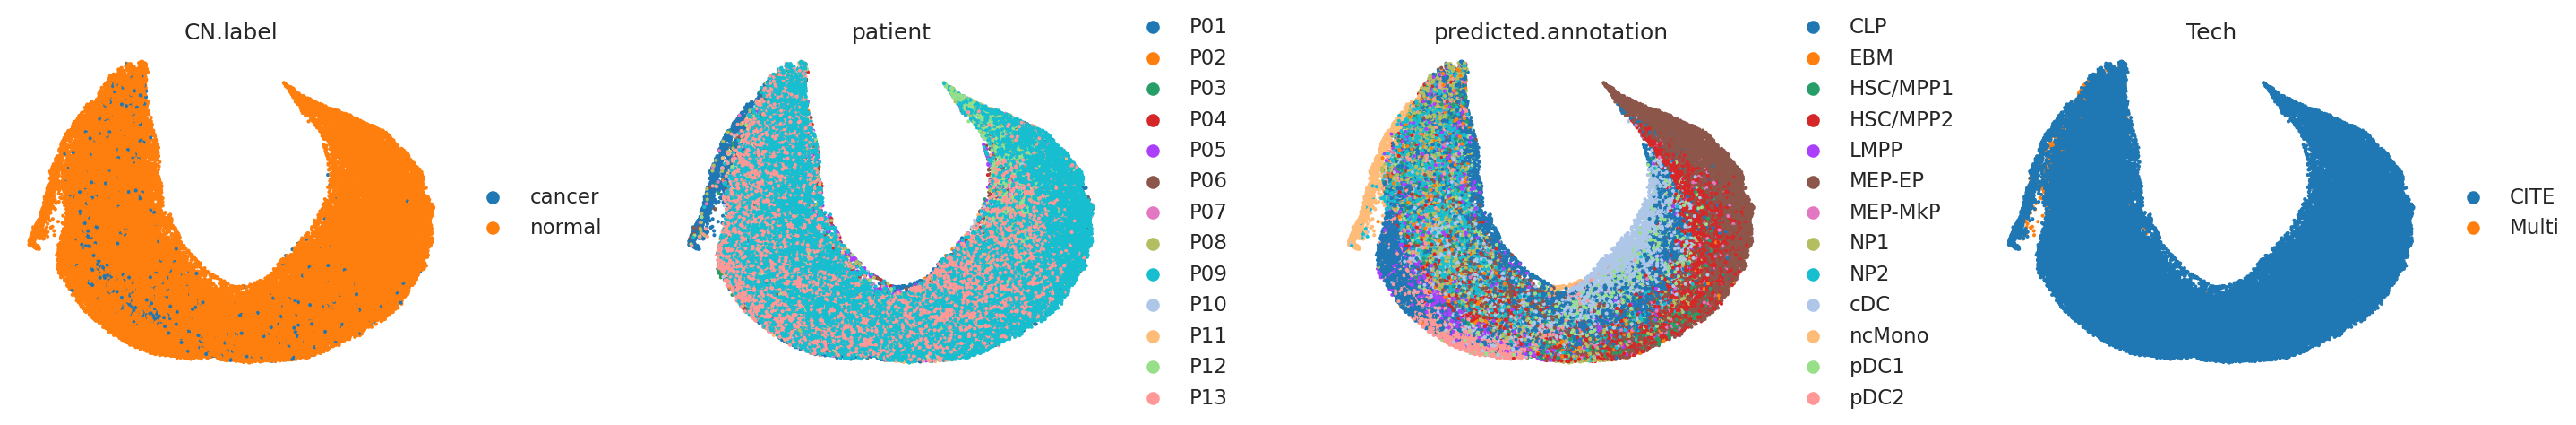


### mean_z


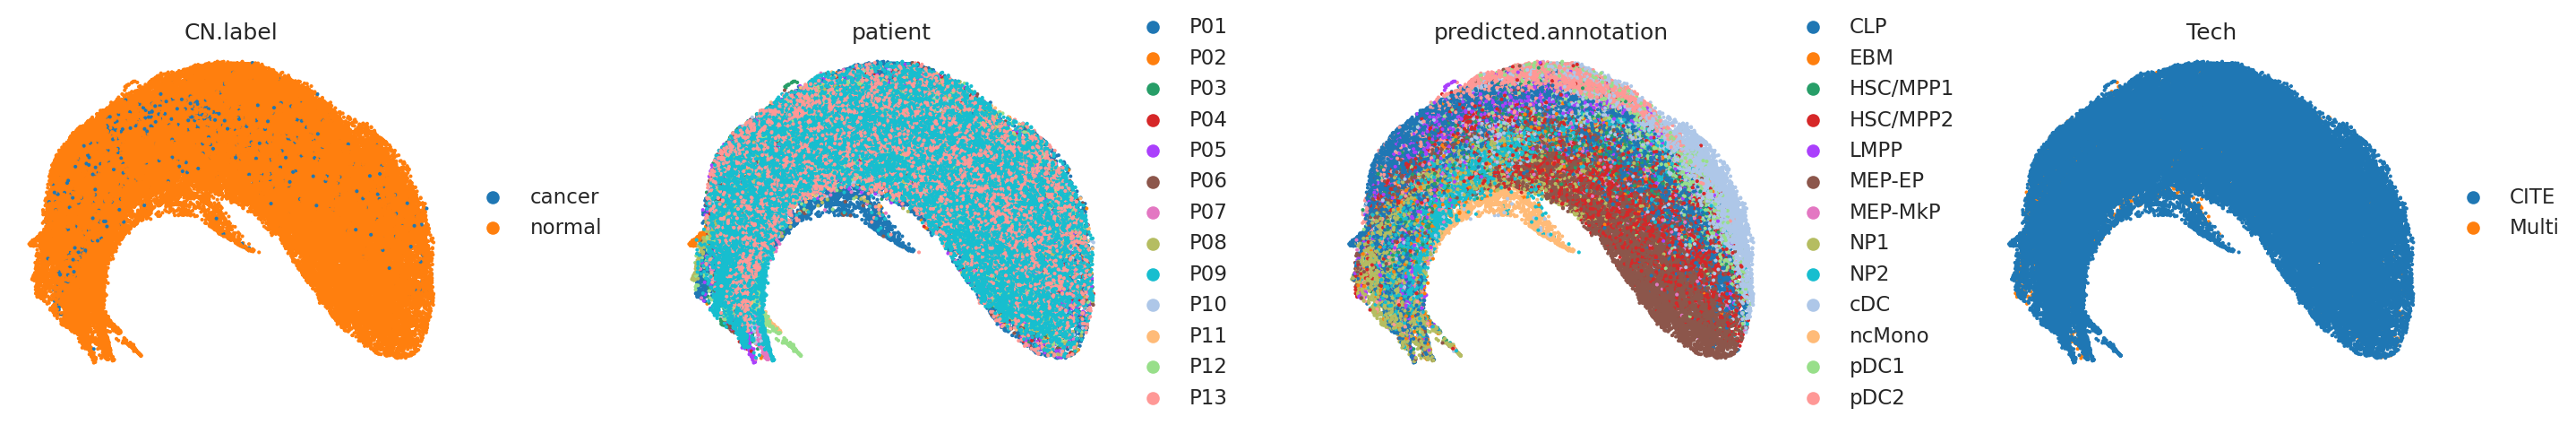


### scoregenes_raw


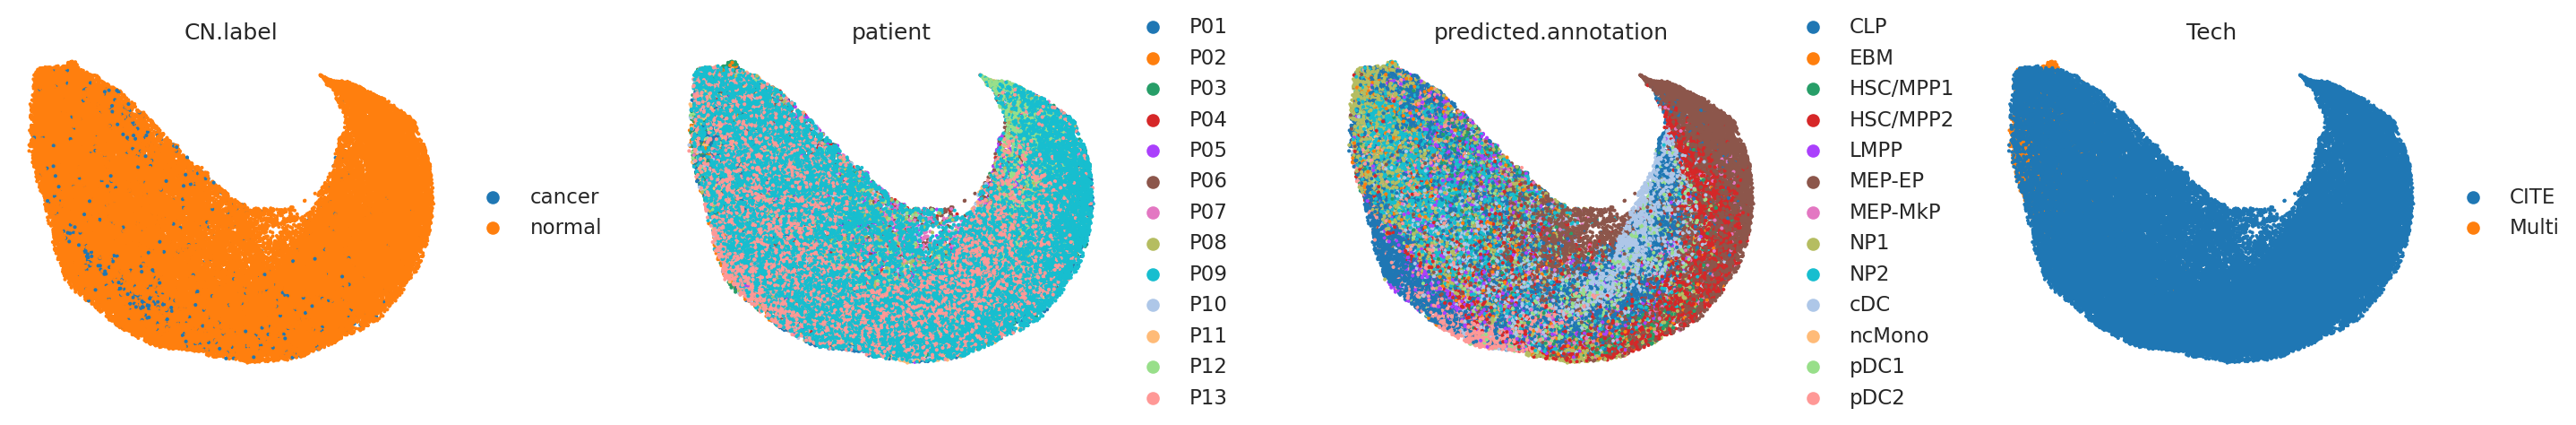


### scoregenes_z


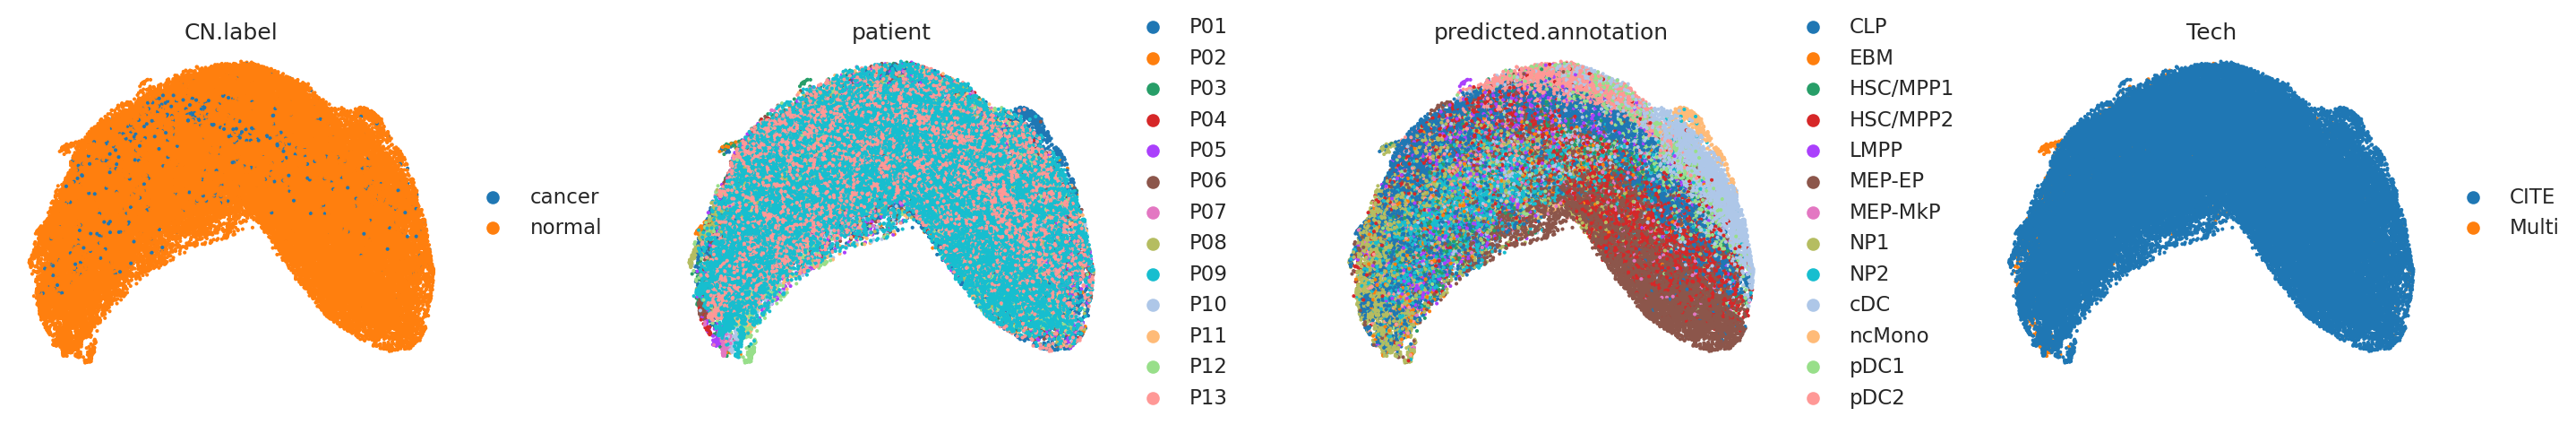

In [16]:
# Visualization: label, patient, time
for method_name, aplot in umap_adatas.items():
    print(f"\n### {method_name}")
    sc.pl.umap(
        aplot,
        color=[CN_LABEL_COL, patient_col, cell_type_col, tech_col],
        wspace=0.35,
        frameon=False,
        size=35,
    )

The geneset-score space does not show strong unsupervised visual stratification by malignant status, patient, or predicted cell type.

Across all tested score constructions, the 34 curated program scores form a relatively smooth manifold rather than clearly separated clusters. In UMAP space, malignant and normal donor cells largely overlap, patient identities are broadly mixed, and predicted cell types show only weak regional enrichment rather than crisp segregation. This suggests that the current pathway-level compression captures broad continuous biological variation but is insufficient, by itself, to induce strong unsupervised separation of these labels.

In [17]:
aplot.var

""
HALLMARK_INTERFERON_GAMMA_RESPONSE
HALLMARK_INTERFERON_ALPHA_RESPONSE
HALLMARK_TNFA_SIGNALING_VIA_NFKB
HALLMARK_INFLAMMATORY_RESPONSE
HALLMARK_IL6_JAK_STAT3_SIGNALING
HALLMARK_IL2_STAT5_SIGNALING
HALLMARK_COMPLEMENT
HALLMARK_ALLOGRAFT_REJECTION
HALLMARK_APOPTOSIS
HALLMARK_P53_PATHWAY


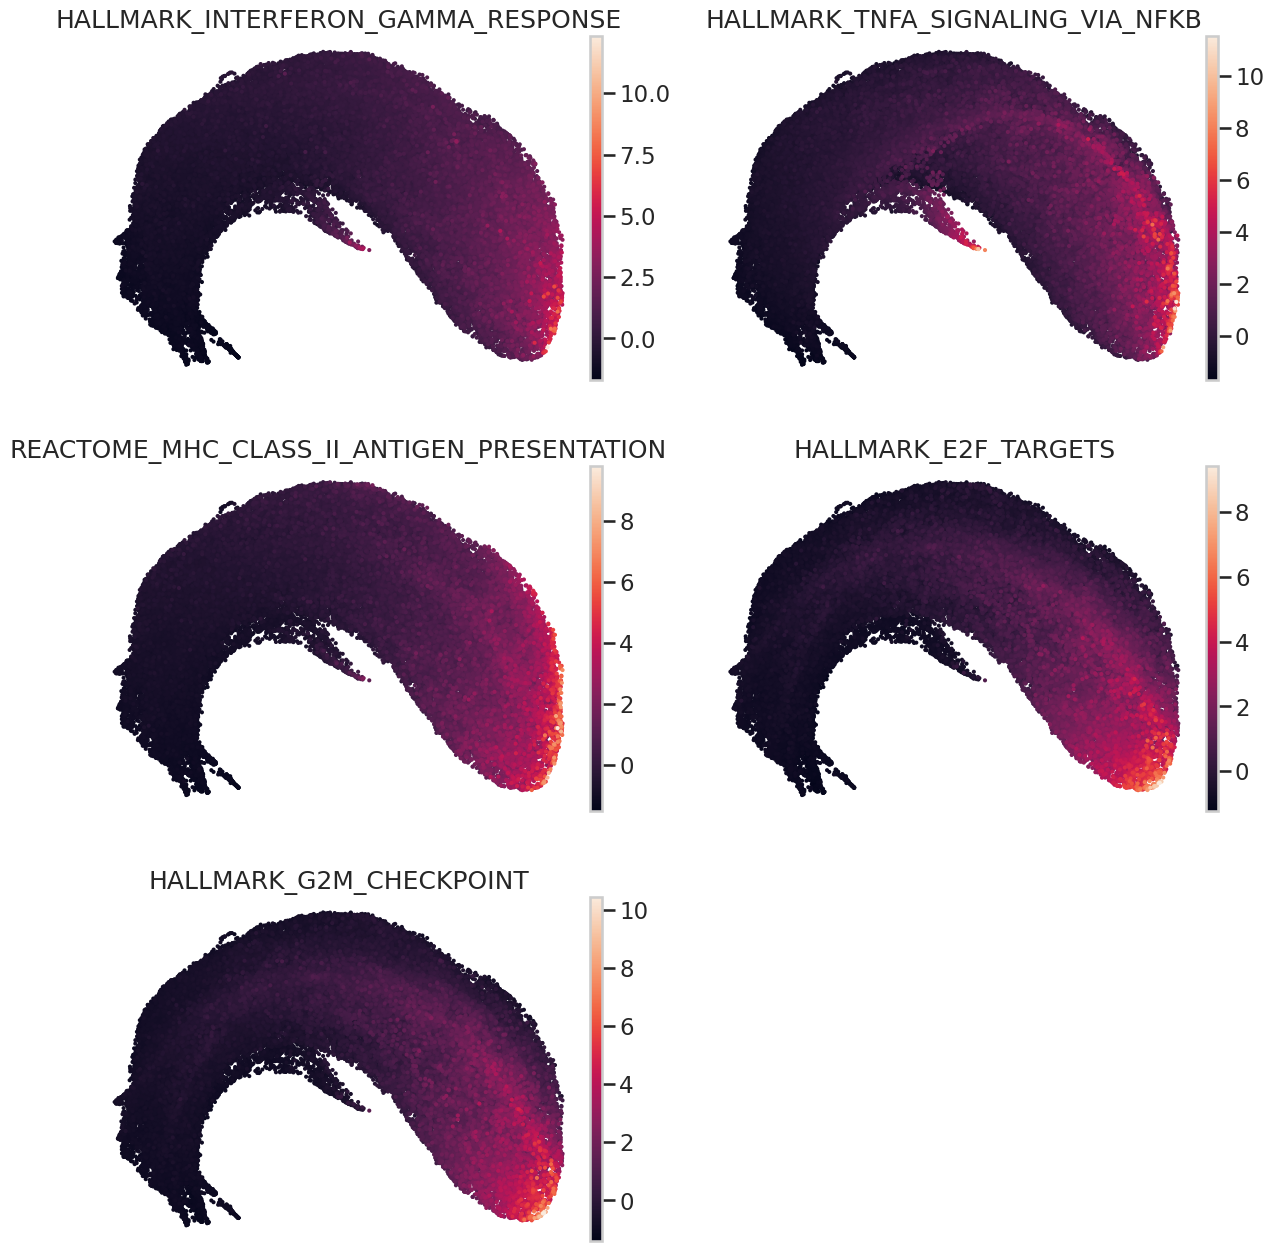

In [18]:
# Optional: visualize individual program scores on UMAP
method_name = "mean_z"  # change as desired
aplot = umap_adatas[method_name]

programs_to_plot = [
    "HALLMARK_INTERFERON_GAMMA_RESPONSE",
    "HALLMARK_TNFA_SIGNALING_VIA_NFKB",
    "REACTOME_MHC_CLASS_II_ANTIGEN_PRESENTATION",
    "HALLMARK_E2F_TARGETS",
    "HALLMARK_G2M_CHECKPOINT",
]

sc.pl.umap(aplot, color=programs_to_plot, ncols=2, frameon=False, size=35)

## 5) Donor-aware benchmark: across-patient and per-patient classification

In [19]:
def get_binary_labels(obs: pd.DataFrame, cn_label_col: str, malignant_values: set[str], normal_values: set[str]) -> pd.Series:
    s = obs[cn_label_col].astype(str)
    y = pd.Series(index=obs.index, dtype="int64")
    y[s.isin(normal_values)] = 0
    y[s.isin(malignant_values)] = 1
    if y.isna().any():
        bad = int(y.isna().sum())
        raise ValueError(f"Found {bad} cells with labels outside malignant/normal values.")
    return y.astype(int)

In [20]:
def make_logreg_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            class_weight="balanced",
            max_iter=5000,
            random_state=42,
        )),
    ])

In [21]:
def evaluate_group_cv(
    X: pd.DataFrame,
    y: pd.Series,
    groups: pd.Series,
    model=None,
    n_splits: int | None = None,
):
    """
    GroupKFold across patients/donors.
    Returns:
      fold_metrics_df
      pred_df (out-of-fold predictions)
    """
    if model is None:
        model = make_logreg_pipeline()

    groups = groups.astype(str)
    uniq_groups = groups.nunique()
    if uniq_groups < 2:
        raise ValueError("Need at least 2 unique groups for group CV.")

    if n_splits is None:
        n_splits = min(5, uniq_groups)
    n_splits = max(2, min(n_splits, uniq_groups))

    cv = GroupKFold(n_splits=n_splits)

    fold_rows = []
    pred_rows = []

    for fold, (tr, te) in enumerate(cv.split(X, y, groups=groups), start=1):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]
        g_te = groups.iloc[te]

        model_fit = make_logreg_pipeline()
        model_fit.fit(X_tr, y_tr)

        p_te = model_fit.predict_proba(X_te)[:, 1]

        auc = roc_auc_score(y_te, p_te)
        auprc = average_precision_score(y_te, p_te)
        brier = brier_score_loss(y_te, p_te)
        ll = log_loss(y_te, np.clip(p_te, 1e-6, 1 - 1e-6))

        fold_rows.append({
            "fold": fold,
            "n_train": len(tr),
            "n_test": len(te),
            "n_test_patients": g_te.nunique(),
            "test_patients": ",".join(sorted(g_te.unique())),
            "auroc": auc,
            "auprc": auprc,
            "brier": brier,
            "log_loss": ll,
        })

        pred_rows.append(pd.DataFrame({
            "cell_id": X_te.index,
            "y_true": y_te.values,
            "p_hat": p_te,
            "group": g_te.values,
            "fold": fold,
        }).set_index("cell_id"))

    fold_metrics_df = pd.DataFrame(fold_rows)
    pred_df = pd.concat(pred_rows, axis=0).loc[X.index]
    return fold_metrics_df, pred_df

In [22]:
def evaluate_within_one_patient(
    X: pd.DataFrame,
    y: pd.Series,
    patient_id: str,
    n_splits: int = 5,
):
    """
    Stratified CV within one patient.
    """
    if y.nunique() < 2:
        return None, None

    class_counts = y.value_counts()
    max_splits = int(class_counts.min())
    n_splits = max(2, min(n_splits, max_splits))
    if max_splits < 2:
        return None, None

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_rows = []
    pred_rows = []

    for fold, (tr, te) in enumerate(cv.split(X, y), start=1):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]

        model_fit = make_logreg_pipeline()
        model_fit.fit(X_tr, y_tr)
        p_te = model_fit.predict_proba(X_te)[:, 1]

        fold_rows.append({
            "patient": patient_id,
            "fold": fold,
            "n_train": len(tr),
            "n_test": len(te),
            "auroc": roc_auc_score(y_te, p_te),
            "auprc": average_precision_score(y_te, p_te),
            "brier": brier_score_loss(y_te, p_te),
            "log_loss": log_loss(y_te, np.clip(p_te, 1e-6, 1 - 1e-6)),
        })

        pred_rows.append(pd.DataFrame({
            "cell_id": X_te.index,
            "patient": patient_id,
            "y_true": y_te.values,
            "p_hat": p_te,
            "fold": fold,
        }).set_index("cell_id"))

    return pd.DataFrame(fold_rows), pd.concat(pred_rows, axis=0).loc[X.index]

In [23]:
def evaluate_per_patient(
    X: pd.DataFrame,
    y: pd.Series,
    patients: pd.Series,
    min_cells: int = 50,
    min_class_cells: int = 10,
):
    all_fold_metrics = []
    all_preds = []

    for pid, idx in patients.groupby(patients.astype(str)).groups.items():
        idx = list(idx)
        Xp = X.loc[idx]
        yp = y.loc[idx]

        if len(idx) < min_cells:
            continue
        vc = yp.value_counts()
        if yp.nunique() < 2:
            continue
        if vc.min() < min_class_cells:
            continue

        fm, pr = evaluate_within_one_patient(Xp, yp, patient_id=pid)
        if fm is None:
            continue
        all_fold_metrics.append(fm)
        all_preds.append(pr)

    if len(all_fold_metrics) == 0:
        return pd.DataFrame(), pd.DataFrame()

    return pd.concat(all_fold_metrics, axis=0, ignore_index=True), pd.concat(all_preds, axis=0)

In [24]:
# Prepare labels and grouping
y_bench = get_binary_labels(
    adata_mrd_benchmark.obs,
    cn_label_col=CN_LABEL_COL,
    malignant_values=MALIGNANT_VALUES,
    normal_values=NORMAL_VALUES,
)

patient_series = adata_mrd_benchmark.obs[patient_col].astype(str)

# Run both across-patient and per-patient benchmarks
results_across = {}
preds_across = {}
results_within = {}
preds_within = {}

for method_name, S in score_mats.items():
    print(f"Running benchmark for {method_name} ...")

    fm_across, pr_across = evaluate_group_cv(
        X=S.loc[adata_mrd_benchmark.obs_names],
        y=y_bench.loc[adata_mrd_benchmark.obs_names],
        groups=patient_series.loc[adata_mrd_benchmark.obs_names],
    )
    results_across[method_name] = fm_across
    preds_across[method_name] = pr_across

    fm_within, pr_within = evaluate_per_patient(
        X=S.loc[adata_mrd_benchmark.obs_names],
        y=y_bench.loc[adata_mrd_benchmark.obs_names],
        patients=patient_series.loc[adata_mrd_benchmark.obs_names],
        min_cells=50,
        min_class_cells=10,
    )
    results_within[method_name] = fm_within
    preds_within[method_name] = pr_within

Running benchmark for mean_raw ...


/home/minhang/miniconda3/envs/sc-classification-rapids-py311/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/minhang/miniconda3/envs/sc-classification-rapids-py311/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/minhang/miniconda3/envs/sc-classification-rapids-py311/lib/python3.11/site-packages/sklearn/linear_model/_

Running benchmark for mean_z ...


/home/minhang/miniconda3/envs/sc-classification-rapids-py311/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/minhang/miniconda3/envs/sc-classification-rapids-py311/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/minhang/miniconda3/envs/sc-classification-rapids-py311/lib/python3.11/site-packages/sklearn/linear_model/_

Running benchmark for scoregenes_raw ...


/home/minhang/miniconda3/envs/sc-classification-rapids-py311/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/minhang/miniconda3/envs/sc-classification-rapids-py311/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/minhang/miniconda3/envs/sc-classification-rapids-py311/lib/python3.11/site-packages/sklearn/linear_model/_

Running benchmark for scoregenes_z ...


/home/minhang/miniconda3/envs/sc-classification-rapids-py311/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/minhang/miniconda3/envs/sc-classification-rapids-py311/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/minhang/miniconda3/envs/sc-classification-rapids-py311/lib/python3.11/site-packages/sklearn/linear_model/_

In [25]:
# Summaries
summary_rows = []

for method_name in score_mats:
    fm_a = results_across[method_name]
    fm_w = results_within[method_name]

    row = {
        "method": method_name,
        "across_mean_auroc": fm_a["auroc"].mean() if len(fm_a) else np.nan,
        "across_mean_auprc": fm_a["auprc"].mean() if len(fm_a) else np.nan,
        "across_mean_brier": fm_a["brier"].mean() if len(fm_a) else np.nan,
        "across_mean_log_loss": fm_a["log_loss"].mean() if len(fm_a) else np.nan,
        "within_mean_auroc": fm_w["auroc"].mean() if len(fm_w) else np.nan,
        "within_mean_auprc": fm_w["auprc"].mean() if len(fm_w) else np.nan,
        "within_mean_brier": fm_w["brier"].mean() if len(fm_w) else np.nan,
        "within_mean_log_loss": fm_w["log_loss"].mean() if len(fm_w) else np.nan,
        "n_within_patients_evaluable": fm_w["patient"].nunique() if len(fm_w) else 0,
    }
    summary_rows.append(row)

benchmark_summary = pd.DataFrame(summary_rows).sort_values(
    ["across_mean_auroc", "across_mean_auprc"],
    ascending=False,
)

display(benchmark_summary)

,method,across_mean_auroc,across_mean_auprc,across_mean_brier,across_mean_log_loss,within_mean_auroc,within_mean_auprc,within_mean_brier,within_mean_log_loss,n_within_patients_evaluable
1,mean_z,0.704209,0.067028,0.182404,0.546027,0.860329,0.381765,0.118871,0.382609,7
3,scoregenes_z,0.703395,0.061729,0.180597,0.541596,0.879802,0.406552,0.110014,0.359544,7
2,scoregenes_raw,0.695888,0.077902,0.171723,0.520354,0.899421,0.474730,0.091758,0.306403,7
0,mean_raw,0.677517,0.074372,0.169211,0.509553,0.879250,0.448520,0.101533,0.334125,7


## Calibration plot

In [26]:
def plot_calibration_from_preds(pred_df: pd.DataFrame, title: str, n_bins: int = 10):
    y_true = pred_df["y_true"].values
    p_hat = pred_df["p_hat"].values

    frac_pos, mean_pred = calibration_curve(y_true, p_hat, n_bins=n_bins, strategy="quantile")

    plt.figure(figsize=(5.5, 5.5))
    plt.plot([0, 1], [0, 1], "--", lw=1.5, label="ideal")
    plt.plot(mean_pred, frac_pos, marker="o", lw=2, label="model")
    plt.xlabel("Predicted probability")
    plt.ylabel("Observed frequency")
    plt.title(title)
    plt.legend(frameon=False)
    plt.show()


Across-patient calibration: mean_raw


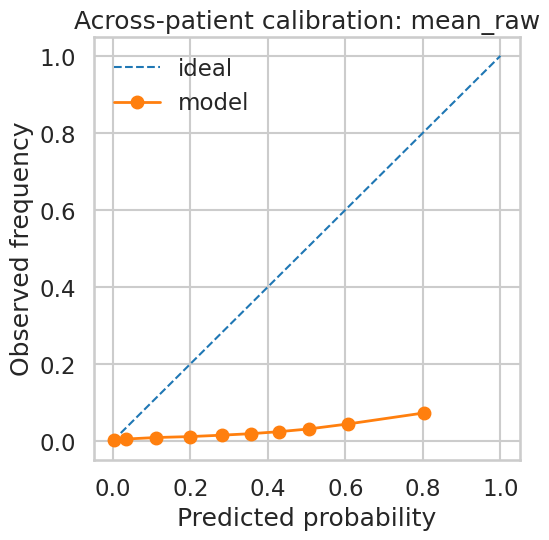


Across-patient calibration: mean_z


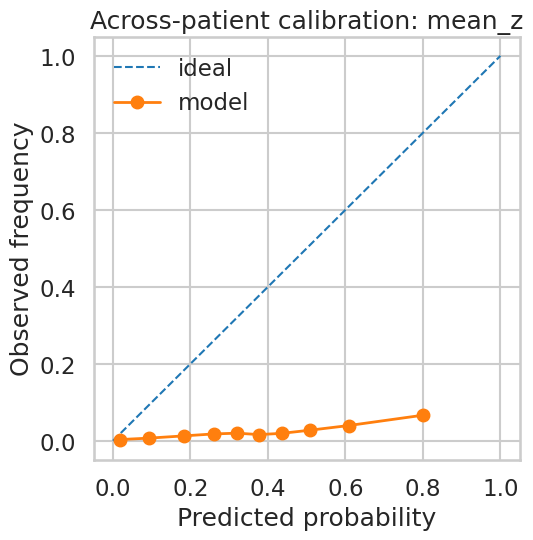


Across-patient calibration: scoregenes_raw


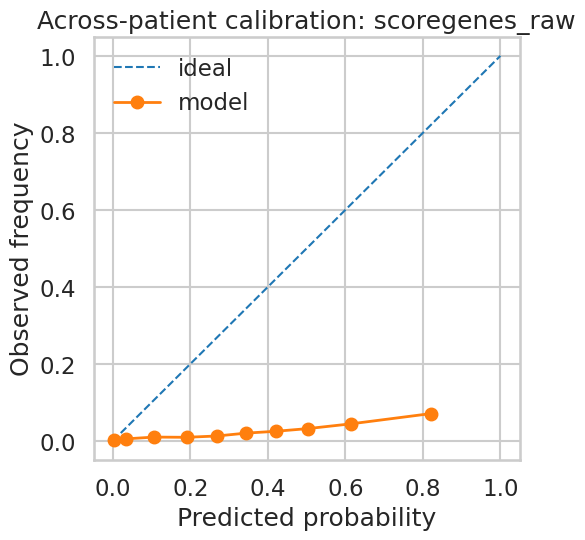


Across-patient calibration: scoregenes_z


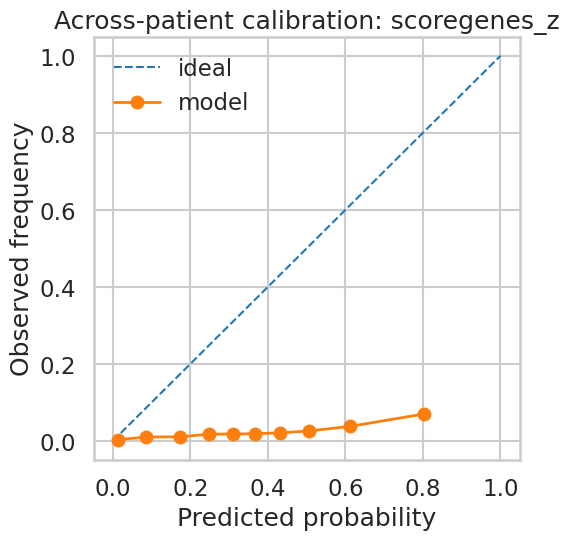

In [27]:
for method_name, pred_df in preds_across.items():
    print(f"\nAcross-patient calibration: {method_name}")
    plot_calibration_from_preds(pred_df, title=f"Across-patient calibration: {method_name}", n_bins=10)


Per-patient pooled calibration: mean_raw


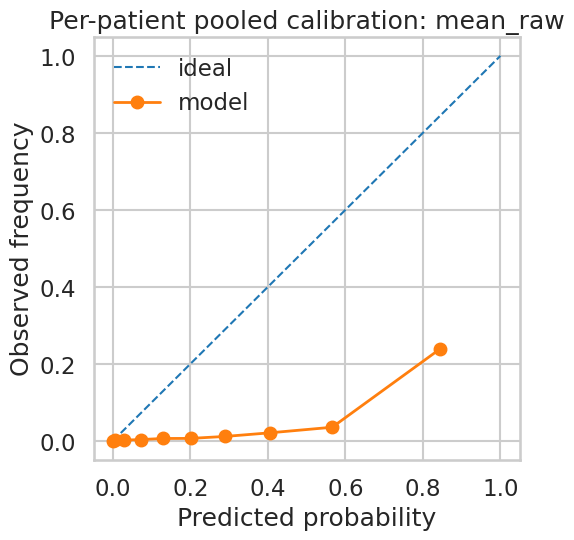


Per-patient pooled calibration: mean_z


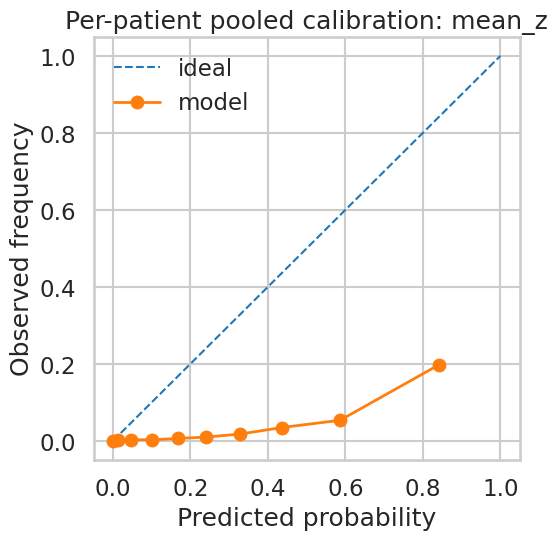


Per-patient pooled calibration: scoregenes_raw


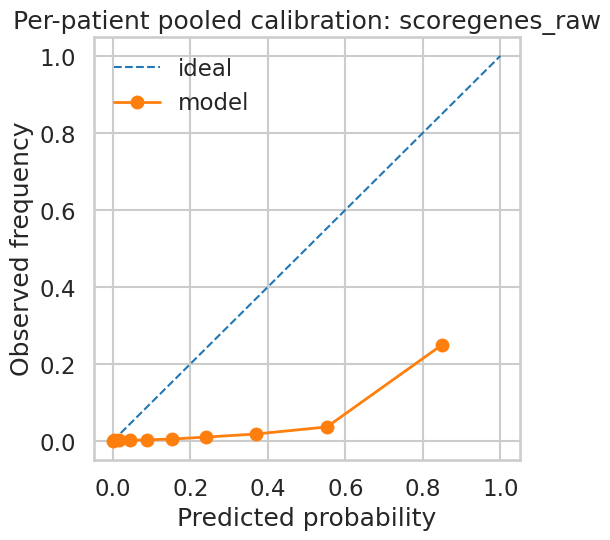


Per-patient pooled calibration: scoregenes_z


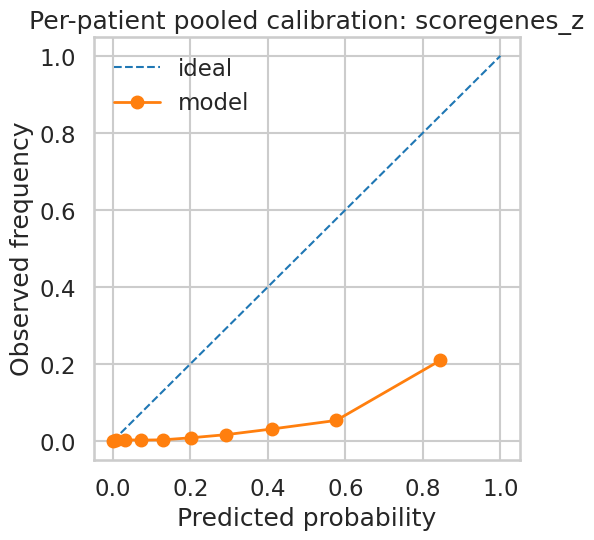

In [28]:
for method_name, pred_df in preds_within.items():
    if len(pred_df) == 0:
        continue
    print(f"\nPer-patient pooled calibration: {method_name}")
    plot_calibration_from_preds(pred_df, title=f"Per-patient pooled calibration: {method_name}", n_bins=10)

In [29]:
# Per-patient AUROC / AUPRC summaries for the within-patient benchmark
within_patient_summary = []

for method_name, fm in results_within.items():
    if len(fm) == 0:
        continue
    tmp = (
        fm.groupby("patient", as_index=False)
        .agg(
            auroc=("auroc", "mean"),
            auprc=("auprc", "mean"),
            brier=("brier", "mean"),
            log_loss=("log_loss", "mean"),
        )
    )
    tmp["method"] = method_name
    within_patient_summary.append(tmp)

within_patient_summary = pd.concat(within_patient_summary, axis=0, ignore_index=True)
display(within_patient_summary.head())

,patient,auroc,auprc,brier,log_loss,method
0,P01,0.786900,0.052325,0.140377,0.455735,mean_raw
1,P02,0.898551,0.613690,0.114612,0.382679,mean_raw
2,P03,0.967977,0.907222,0.061739,0.226489,mean_raw
3,P04,0.918017,0.682364,0.095459,0.321251,mean_raw
4,P06,0.733502,0.107062,0.142371,0.448863,mean_raw


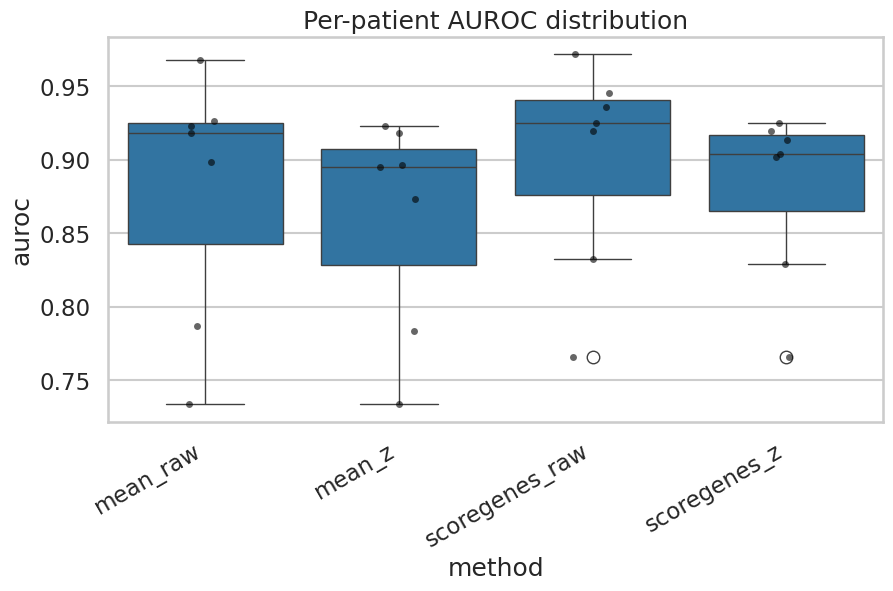

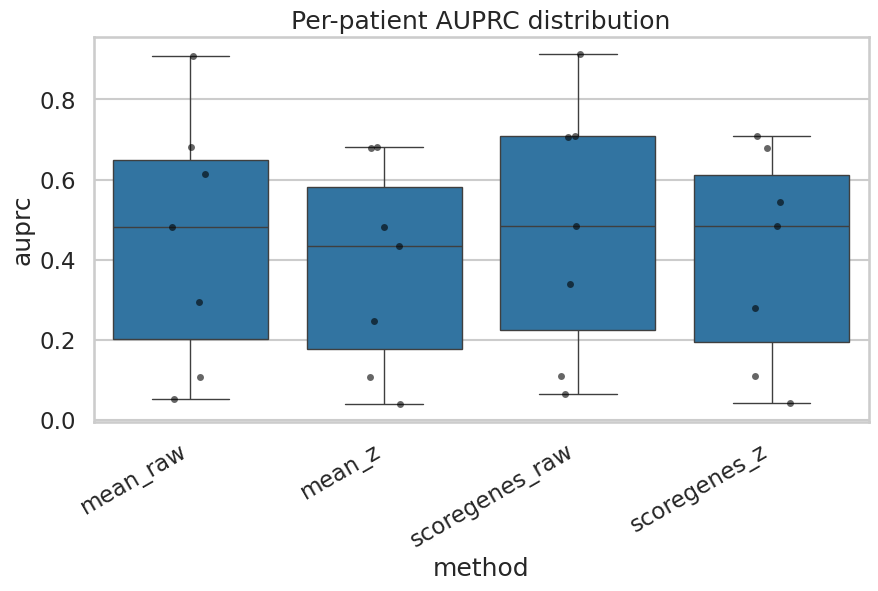

In [30]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=within_patient_summary, x="method", y="auroc")
sns.stripplot(data=within_patient_summary, x="method", y="auroc", color="black", alpha=0.6)
plt.xticks(rotation=30, ha="right")
plt.title("Per-patient AUROC distribution")
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=within_patient_summary, x="method", y="auprc")
sns.stripplot(data=within_patient_summary, x="method", y="auprc", color="black", alpha=0.6)
plt.xticks(rotation=30, ha="right")
plt.title("Per-patient AUPRC distribution")
plt.show()